# Problem 1

Theoretical drug release kinetics. In class we described a situation where drug is released from a polymer at a certain rate. However, more commonly drug release occurs when the polymer is degraded or eroded. Assume that the rate of polymer erosion at the surface equals the rate of diffusion of polymer from the surface. 

## Problem 1a

Show that a material balance leads to the following relation for the polymer (Cp is the polymer concentration in undissolved state, and p subscript represents the polymer):

$ -[C]_p \frac{dR^3}{dt} = 3R^2 N_{pr} |_{r=R}$

Polymer in sphere:

$n_p = [C]_p \cdot V = [C]_p \cdot \frac{4}{3}\pi R^3$

Substituting:

$\frac{d}{dt}\left([C]_p \cdot \frac{4}{3}\pi R^3\right) = -N_{pr}\big|_{r=R} \cdot 4\pi R^2$

$\implies [C]_p \cdot \frac{4}{3}\pi \cdot \frac{dR^3}{dt} = -N_{pr}\big|_{r=R} \cdot 4\pi R^2$

$\implies [C]_p \frac{dR^3}{dt} = -3R^2\, N_{pr}\big|_{r=R}$

$\boxed{-[C]_p \frac{dR^3}{dt} = 3R^2\, N_{pr}\big|_{r=R}}$


## Problem 1b

Determine the flux, assuming steady-state diffusion of the polymer away from the surface. The concentration of polymer in solution is a partition coefficient times the polymer concentration:

$[C]_{p,solution} (r=R) = \phi_p [C]_p $

$J(R) = \frac{D_{\psi_p}[C]_p}{R}$


$\frac{1}{r^2}\frac{d}{dr}\!\left(r^2\frac{dC}{dr}\right) = 0$

Integrate once, then again:

$r^2\frac{dC}{dr} = B_1 \implies C(r) = -\frac{B_1}{r} + B_2$

Apply BCs: $C(r\to\infty) = 0 \implies B_2 = 0$; $\quad C(R) = \phi_p[C]_p \implies B_1 = -\phi_p[C]_p R$

$\therefore\quad C(r) = \frac{\phi_p[C]_p R}{r}, \quad r \geq R$

$J = -D_p\frac{dC}{dr} = \frac{D_p \phi_p[C]_p R}{r^2}$

$\boxed{J(R) = \frac{D_p \phi_p[C]_p}{R} \equiv \frac{D_{\phi_p}[C]_p}{R}}$

## Problem 1c

Use part b to solve the material balance relation in part a, and find an analytical equation for R(t). 

$R(t) = \sqrt{R_0^2 - 2D_{\psi_p} t}$

$-[C]_p \frac{dR^3}{dt} = 3R^2 \frac{D_{\phi_p}[C]_p}{R} \implies -R\,\frac{dR}{dt} = D_{\phi_p}$

Separate and integrate:

$\int_{R_0}^{R} R\, dR = -D_{\phi_p}\int_0^t dt$

$\frac{1}{2}(R^2 - R_0^2) = -D_{\phi_p}\, t$

$\boxed{R(t) = \sqrt{R_0^2 - 2D_{\phi_p}\, t}}$

# Problem 2

Empirical drug release rates. You plan two experiments to determine the type of transport that governs a small molecule drug releasing from 5 $\mu$ m diameter poly(dimethylsiloxane) microparticles. The initial mass of your drug is 400 $\mu$ g loaded into the microparticles, and you know that the effective diffusivity of your drug is $2.44x10^{-5} cm^2 / s$

## Problem 2a
First, you design a drug release study to fit parameters to the Korsmeyer-Peppas model. At various time points, you quantify the mass of drug released into the release medium in triplicate. The data for this experiment can be found in the appendix. Determine the most likely parameter values for n and k. What do the fitted parameters tell you about the mass transport mechanism out of the particle?


n = 0.8058
k = 0.1532 h^(-n)
R² = 0.9987


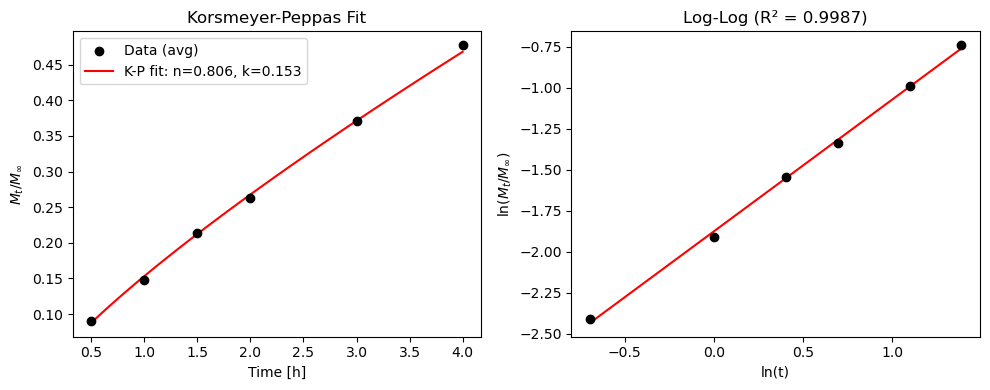

With $n \approx 0.81$, this means the polymer can be modeled with a Fickian diffusion contribution.


In [3]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Raw data
time = np.array([0, 0.5, 1, 1.5, 2, 3, 4, 6, 8])
M_rep1 = np.array([0.033299, 35.50551, 59.43579, 85.25855, 116.1476, 159.9308, 180.3928, 250.63,  345.261 ])
M_rep2 = np.array([0.00885,  37.60932, 60.66476, 85.49945, 102.9387, 149.5979, 198.2194, 275.8177, 324.0748])
M_rep3 = np.array([0.020807, 34.67678, 57.76742, 85.55454, 96.43742, 135.9958, 194.0663, 270.0115, 328.268 ])

M_inf = 400  # ug

# Average triplicates, compute fractional release
M_avg = (M_rep1 + M_rep2 + M_rep3) / 3
f = M_avg / M_inf  # Mt/M_inf

# KP model valid only for f <= 0.60, exclude t=0
mask = (f <= 0.60) & (time > 0)
t_fit = time[mask]
f_fit = f[mask]

# Log-transform for linear regression
x = np.log(t_fit)
y = np.log(f_fit)

# Linear regression
slope, intercept, r, p, se = stats.linregress(x, y)
n = slope
k = np.exp(intercept)

print(f"n = {n:.4f}")
print(f"k = {k:.4f} h^(-n)")
print(f"R² = {r**2:.4f}")

# Plot
t_plot = np.linspace(0.5, 4, 100)
f_pred = k * t_plot**n

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.scatter(t_fit, f_fit, color='k', zorder=5, label='Data (avg)')
ax1.plot(t_plot, f_pred, 'r-', label=f'K-P fit: n={n:.3f}, k={k:.3f}')
ax1.set_xlabel('Time [h]')
ax1.set_ylabel('$M_t / M_\\infty$')
ax1.set_title('Korsmeyer-Peppas Fit')
ax1.legend()

ax2.scatter(np.log(t_fit), np.log(f_fit), color='k', zorder=5)
ax2.plot(np.log(t_plot), np.log(k) + n*np.log(t_plot), 'r-')
ax2.set_xlabel('ln(t)')
ax2.set_ylabel('ln($M_t / M_\\infty$)')
ax2.set_title(f'Log-Log (R² = {r**2:.4f})')
plt.tight_layout()
plt.show()

print(r"With $n \approx 0.81$, this means the polymer can be modeled with a Fickian diffusion contribution.")


## Problem 2b


Next, you perform rheology to determine the shear modulus of the polymer, and therefore, the viscoelastic relaxation time ($t_c = 0.0087s$). From this information, calculate the Deborah number. Is this result consistent with the mass transport mechanism you found in part (a)?


## Problem 2b

$De = \frac{t_c}{t_{\text{diff}}}, \qquad t_{\text{diff}} = \frac{R^2}{D} = \frac{(2.5\times10^{-4})^2}{2.44\times10^{-5}} = 2.56\times10^{-3}\text{ s}$

$\boxed{De = \frac{0.0087}{2.56\times10^{-3}} \approx 3.4}$

$De > 1 \implies$ relaxation slower than diffusion $\implies$ anomalous transport, consistent with $n \approx 0.81$ from (a).

# Problem 3

Draft a 1-page abstract of your final project. This should be written as a prospectus in which you state the system you which to analyze or model, the significance of the system (why are you interested in this system?), the type of analysis performed, and expected results. These types of projects work best when they relate somehow to your major thesis project, and I strongly encourage some overlap! This abstract should be 250-300 words with a graphical abstract similar to ACS publications. I strongly encourage you to discuss the project with me ahead of the PS due date. 

### Abstract

Working Title: An Ordinary Differential Equations Framework for Lipoprotein(a) Expression Dynamics as a Function of Copy Number Variation Length 

Lipoprotein(a) [Lp(a)] is a highly atherogenic, prothrombotic, and proinflammatory lipoprotein with well-established causal associations with cardiovascular disease (CVD) risk. A defining feature of Lp(a) is the Kringle IV Type 2 (KIV-2) variable number tandem repeat (VNTR) region within the *LPA* gene, which encodes the apolipoprotein(a) [apo(a)] protein. KIV-2 copy number ranges from 1–40 repeats and accounts for 40–70% of variation in circulating Lp(a) concentrations, with shorter repeat lengths typically associated with higher endogenous Lp(a) concentrations. Despite >70% heritability and co-dominant structure, the mechanistic basis for this inverse relationship remains incompletely understood. The prevailing hypothesis implicates endoplasmic reticulum (ER) protein trafficking as the central regulatory bottleneck. Longer apo(a) isoforms require more extensive post-translational modification, before export, in turn, increasing exposure to ER-associated degradation (ERAD) machinery. This project develops an ordinary differential equation (ODE) model of apo(a) synthesis, folding, trafficking, and degradation as a function of KIV-2 repeat number. The model will incorporate: (1) isoform-length-dependent ER processing rates, (2) ERAD-mediated degradation as a function of ER processing time, and (3) secretion and hepatic assembly into Lp(a) particles. Expected results include steady-state apo(a) secretion curves as a function of repeat number that recapitulate the experimentally observed inverse relationship between KIV-2 copy number and Lp(a) concentration. Bifurcation and sensitivity analyses will identify rate-limiting steps in trafficking and degradation, with implications for therapeutic targeting of Lp(a) biosynthesis. Broadly, this framework may inform haplotype informed polygenic risk score construction for Lp(a)-associated CVD, supporting more equitable cardiovascular risk prediction across genetically diverse populations.

### Graphical Abstract


![Insert Image Here](../PS10/LMM.gif "Title") 

For actual graphical abstract please see below. 

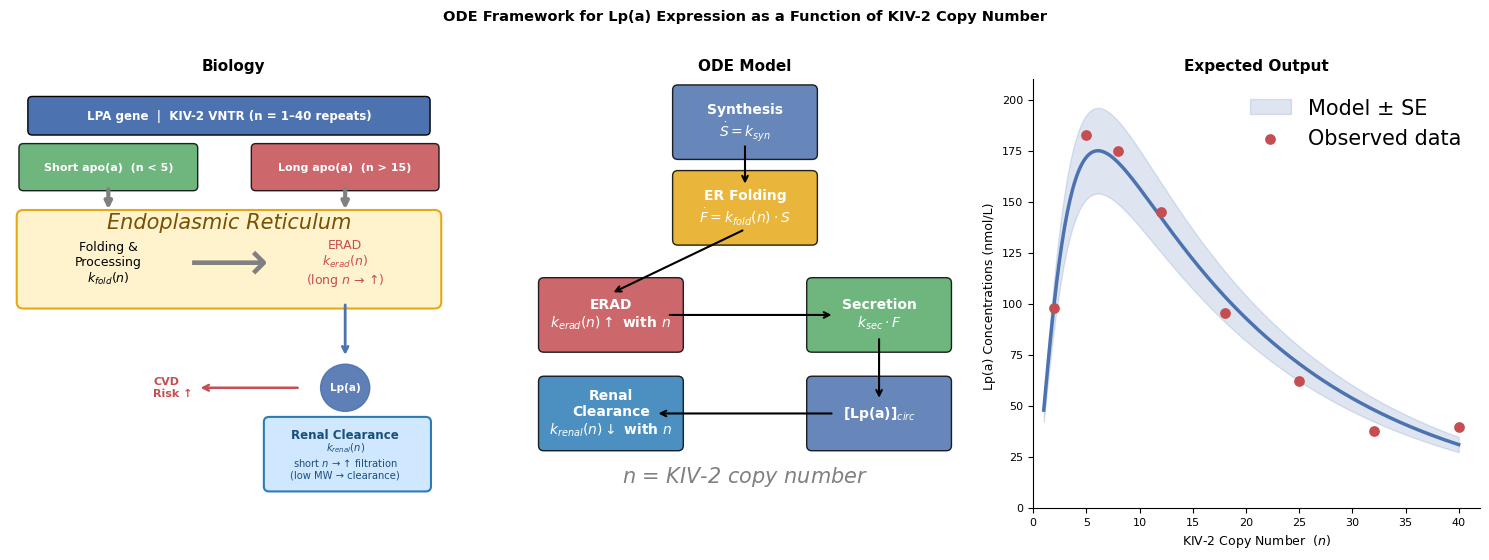

In [114]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.patch.set_facecolor('white')
for ax in axes[:2]:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

# ── PANEL 1: Biology ──────────────────────────────────────────────────────────
ax = axes[0]
ax.set_title('Biology', fontsize=11, fontweight='bold', pad=6)

# LPA gene bar
ax.add_patch(FancyBboxPatch((0.5, 8.8), 8.8, 0.7, boxstyle="round,pad=0.1",
    facecolor='#4C72B0', edgecolor='k', linewidth=1))
ax.text(4.9, 9.15, r'LPA gene  |  KIV-2 VNTR (n = 1–40 repeats)', 
    ha='center', va='center', color='white', fontsize=8.5, fontweight='bold')

# Short vs long isoform labels
ax.add_patch(FancyBboxPatch((0.3, 7.5), 3.8, 0.9, boxstyle="round,pad=0.1",
    facecolor='#55A868', edgecolor='k', linewidth=1, alpha=0.85))
ax.text(2.2, 7.95, 'Short apo(a)  (n < 5)', ha='center', va='center',
    color='white', fontsize=8, fontweight='bold')

ax.add_patch(FancyBboxPatch((5.5, 7.5), 4.0, 0.9, boxstyle="round,pad=0.1",
    facecolor='#C44E52', edgecolor='k', linewidth=1, alpha=0.85))
ax.text(7.5, 7.95, 'Long apo(a)  (n > 15)', ha='center', va='center',
    color='white', fontsize=8, fontweight='bold')

# ER box
ax.add_patch(FancyBboxPatch((0.3, 4.8), 9.2, 2, boxstyle="round,pad=0.15",
    facecolor='#FFF3CD', edgecolor='#E6A817', linewidth=1.5))
ax.text(4.9, 6.65, 'Endoplasmic Reticulum', ha='center', va='center',
    fontsize=15, style='italic', color='#7A5000')
ax.text(2.2, 5.7, 'Folding &\nProcessing\n$k_{fold}(n)$', ha='center', va='center', fontsize=9)
ax.text(4.9, 5.7, '⟶', ha='center', va='center', fontsize=40, color='gray')
ax.text(7.5, 5.7, 'ERAD\n$k_{erad}(n)$\n(long $n$ → ↑)', ha='center', va='center',
    fontsize=9, color='#C44E52')

# Arrows gene → ER
ax.annotate('', xy=(2.2, 6.9), xytext=(2.2, 7.5),
    arrowprops=dict(arrowstyle='->', color='gray', lw=3))
ax.annotate('', xy=(7.5, 6.9), xytext=(7.5, 7.5),
    arrowprops=dict(arrowstyle='->', color='gray', lw=3))

# Secretion → Lp(a)
ax.annotate('', xy=(7.5, 3.5), xytext=(7.5, 4.8),
    arrowprops=dict(arrowstyle='->', color='#4C72B0', lw=2))
ax.add_patch(plt.Circle((7.5, 2.8), 0.55, color='#4C72B0', alpha=0.9))
ax.text(7.5, 2.8, 'Lp(a)', ha='center', va='center',
    color='white', fontsize=7.5, fontweight='bold')

# CVD arrow
ax.annotate('', xy=(4.2, 2.8), xytext=(6.5, 2.8),
    arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.8))
ax.text(3.2, 2.8, 'CVD\nRisk ↑', ha='left', va='center',
    fontsize=8, color='#C44E52', fontweight='bold')

# ── KIDNEY BOX (new) ──
ax.add_patch(FancyBboxPatch((5.8, 0.5), 3.5, 1.5, 
                            boxstyle="round,pad=0.12",
    facecolor='#D0E8FF', edgecolor='#2C7BB6', linewidth=1.5))
ax.text(7.5, 1.7, 'Renal Clearance', ha='center', va='center',
    fontsize=8.5, fontweight='bold', color='#1A4F7A')
ax.text(7.5, 1.1, 
    '$k_{renal}(n)$\nshort $n$ → ↑ filtration\n(low MW → clearance)',
    ha='center', va='center', fontsize=7.2, color='#1A4F7A')

# Arrow Lp(a) → kidney (short isoform only)
# ax.annotate('', xy=(1.4, 2.5), xytext=(1.8, 2.75),
#     arrowprops=dict(arrowstyle='->', color='#2C7BB6', lw=1.8,
#     connectionstyle='arc3,rad=0.3'))
# ax.text(0.35, 2.65, 'short $n$\nonly', ha='center', va='center',
#     fontsize=6.5, color='#2C7BB6', style='italic')

# ── PANEL 2: ODE Model ───────────────────────────────────────────────────────
ax = axes[1]
ax.set_title('ODE Model', fontsize=11, fontweight='bold', pad=6)

compartments = [
    (5.0, 9.0, 'Synthesis\n$\\dot{S} = k_{syn}$',                '#4C72B0'),
    (5.0, 7.0, 'ER Folding\n$\\dot{F} = k_{fold}(n)\\cdot S$',  '#E6A817'),
    (2.0, 4.5, 'ERAD\n$k_{erad}(n) \\uparrow$ with $n$',        '#C44E52'),
    (8.0, 4.5, 'Secretion\n$k_{sec}\\cdot F$',                   '#55A868'),
    (8.0, 2.2, '[Lp(a)]$_{circ}$',                               '#4C72B0'),
    (2.0, 2.2, 'Renal\nClearance\n$k_{renal}(n)\\downarrow$ with $n$', '#2C7BB6'),
]
for (x, y, label, col) in compartments:
    ax.add_patch(FancyBboxPatch((x-1.5, y-0.75), 3.0, 1.5, boxstyle="round,pad=0.12",
        facecolor=col, edgecolor='k', linewidth=1, alpha=0.85))
    ax.text(x, y, label, ha='center', va='center',
        color='white', fontsize=10, fontweight='bold')

# Arrows
arrow_pairs = [
    (5.0, 8.5, 5.0, 7.5),   # synth → fold
    (5, 6.5,  2.0, 5),   # fold → ERAD
    (3.25, 4.5, 7.0, 4.5),    # ERAD → secretion
    (8.0, 4, 8.0, 2.5),   # sec → Lp(a)
    (7, 2.2,  3, 2.2),    # Lp(a) → renal
]
for (x1, y1, x2, y2) in arrow_pairs:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color='k', lw=1.5))

ax.text(5.0, 0.6, '$n$ = KIV-2 copy number', ha='center', fontsize=15,
    color='gray', style='italic')

# ── PANEL 3: Expected Output ─────────────────────────────────────────────────
ax = axes[2]
ax.set_title('Expected Output', fontsize=11, fontweight='bold', pad=6)
ax.axis('on')
ax.set_xlim(0, 42)
ax.set_ylim(0, 210)
ax.set_xlabel('KIV-2 Copy Number  ($n$)', fontsize=9)
ax.set_ylabel('Lp(a) Concentrations (nmol/L) ', fontsize=9)
ax.tick_params(labelsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Parabolic curve: kidney clearance at low n, ERAD at high n
n_vals = np.linspace(1, 40, 300)
k_renal = np.exp(-0.35 * n_vals)          # short n → fast renal clearance
k_erad  = np.exp(-0.055 * n_vals)         # long n → ERAD accumulates
lpa = 190 * (1 - np.exp(-0.6 * n_vals)) * k_erad * (1 - 0.85 * k_renal)
lpa = lpa / lpa.max() * 175               # normalize peak ~175

ax.plot(n_vals, lpa, color='#4C72B0', lw=2.5, zorder=3)
ax.fill_between(n_vals, lpa * 0.88, lpa * 1.12,
    color='#4C72B0', alpha=0.18, label='Model ± SE')

# Simulated data scatter
np.random.seed(42)
n_pts = np.array([2, 5, 8, 12, 18, 25, 32, 40])
lpa_pts = np.interp(n_pts, n_vals, lpa) + np.random.uniform(-12, 12, len(n_pts))
ax.scatter(n_pts, lpa_pts, color='#C44E52', zorder=5, s=45, label='Observed data')

# Regime annotations
# ax.axvspan(0,  5,  alpha=0.07, color='#2C7BB6')
# ax.axvspan(5,  15, alpha=0.07, color='#55A868')
# ax.axvspan(15, 42, alpha=0.07, color='#C44E52')

# ax.text(2.5,  195, 'Renal\nclearance', ha='center', fontsize=6.8,
#     color='#2C7BB6', fontweight='bold')
# ax.text(10,   195, 'Peak\n[Lp(a)]',   ha='center', fontsize=6.8,
#     color='#55A868', fontweight='bold')
# ax.text(28,   195, 'ERAD\ndominates', ha='center', fontsize=6.8,
#     color='#C44E52', fontweight='bold')

# ax.axvline(5,  color='gray', lw=0.8, ls='--', alpha=0.6)
# ax.axvline(15, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.legend(fontsize=15, frameon=False, loc='upper right')

plt.suptitle('ODE Framework for Lp(a) Expression as a Function of KIV-2 Copy Number',
    fontsize=10.5, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lp(a)_model.png', dpi=300, bbox_inches='tight')
plt.show()


# Location of Jupyter Notebook

This file was created in jupyter notebook, rendered into `.html` through `jupyter nbconvert --to html PS11/PS11.ipynb` then the `.html` file was saved as a `.pdf`. The location of all said files are [github.com/caterer-z-t/CHEN_5150/PS11](https://github.com/caterer-z-t/CHEN_5150/tree/main/PS11)

Please contact [ztcaterer@colorado.edu](mailto:ztcaterer@colorado.edu) if there are any issues or concerns. 

Thanks :-)

### Disclosure
Generative artificial intelligence tools were used to assist with this project. All generated content was reviewed, edited, and verified by the authors, who take full responsibility for the accuracy, integrity, and final content of this work. 